In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

import arviz as az
import pymc as pm

# Bayesian linear regression

Variation of:

 - https://www.pymc.io/projects/examples/en/latest/causal_inference/GLM-simpsons-paradox.html


In [ ]:
np.random.seed(2)
group_list = ["one", "two", "three", "four", "five"]
trials_per_group = 20
group_intercepts = np.random.normal(0, 1, len(group_list))
group_slopes = np.ones(len(group_list)) * -0.5
group_mx = group_intercepts * 2
group = np.repeat(group_list, trials_per_group)
subject = np.concatenate([np.ones(trials_per_group) * i for i in np.arange(len(group_list))]).astype(int)
intercept = np.repeat(group_intercepts, trials_per_group)
slope = np.repeat(group_slopes, trials_per_group)
mx = np.repeat(group_mx, trials_per_group)
x = np.random.normal(mx, 1)
y = np.random.normal(intercept + (x - mx) * slope, 1)
data = pd.DataFrame({"group": group, "group_idx": subject, "x": x, "y": y})
data.head()


,group,group_idx,x,y
0,one,0,-1.675263,2.589411
1,one,0,-0.330634,1.167134
2,one,0,-2.078804,0.646576
3,one,0,-1.891468,-0.607036
4,one,0,-1.742523,-0.545669


<Axes: xlabel='x', ylabel='y'>

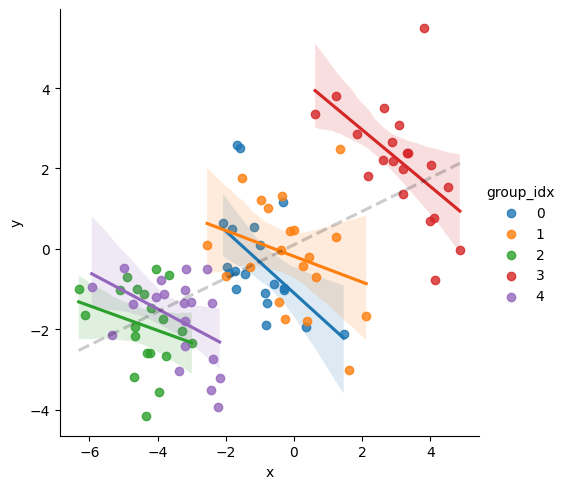

In [ ]:
sns.lmplot(data=data, x="x", y="y", hue="group_idx", order=1)
sns.regplot(data=data, x="x", y="y",scatter=False,ci=None,line_kws=dict(color='k',ls="--",alpha=0.2))

**Chat**,
1. Explain Simpson's paradox in one sentence, and the way to deal with it in another.
2. Give me some famous real life examples of **Simpson's paradox**. Mention the original Berkley bias case and COVID-19 in Italy.


### Basic regression model
$$y = \beta_0 + \beta_1 \cdot x + N(0,\sigma) $$
$$y = N(\beta_0 + \beta_1 \cdot x,\sigma) $$

- no groups.

Output()

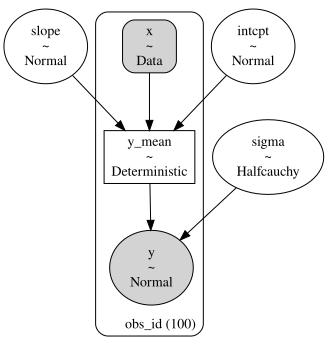

In [ ]:
regress = pm.Model()
with regress:
    sigma = pm.HalfCauchy("sigma", beta=2)
    intcpt = pm.Normal("intcpt", 0, sigma=5)
    slope = pm.Normal("slope", 0, sigma=5)
    x = pm.Data("x", data.x, dims="obs_id")
    y_mean = pm.Deterministic("y_mean", intcpt + slope * x, dims="obs_id")
    pm.Normal("y", mu=y_mean, sigma=sigma, observed=data.y, dims="obs_id")
    idata = pm.sample(3000,chains=2)
pm.model_to_graphviz(regress)

**Chat**,
1. <Copy & paste> What is this pymc model doing?
2. Why are the priors reasonable? What's HalfCauchy?

## Inference



array([<Axes: title={'center': 'intcpt'}>,
       <Axes: title={'center': 'sigma'}>,
       <Axes: title={'center': 'slope'}>], dtype=object)

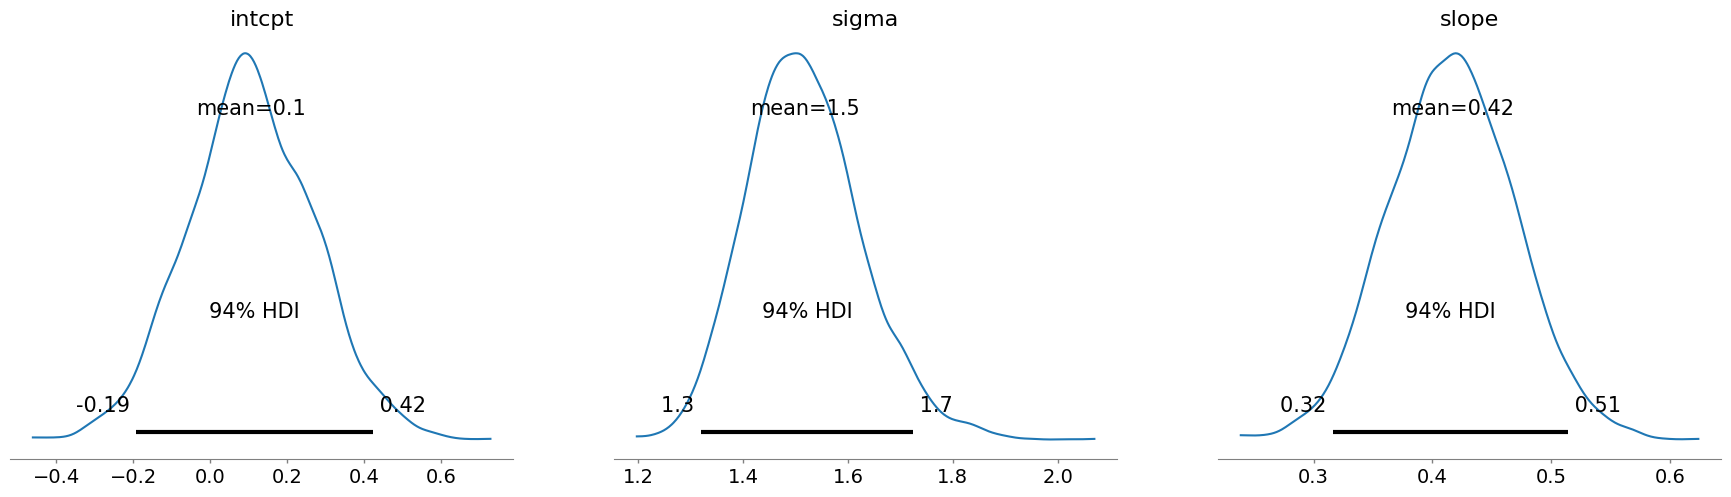

In [ ]:
az.plot_posterior(idata, var_names=["~y_mean"])

In [ ]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [ ]:
idata.posterior[["intcpt","slope","sigma"]]

<xarray.Dataset> Size: 168kB
Dimensions:  (chain: 2, draw: 3000)
Coordinates:
  * chain    (chain) int64 16B 0 1
  * draw     (draw) int64 24kB 0 1 2 3 4 5 6 ... 2994 2995 2996 2997 2998 2999
Data variables:
    intcpt   (chain, draw) float64 48kB -0.07897 -0.3257 ... 0.5619 0.04989
    slope    (chain, draw) float64 48kB 0.3403 0.3467 0.3431 ... 0.4482 0.3751
    sigma    (chain, draw) float64 48kB 1.669 1.612 1.6 ... 1.556 1.625 1.465
Attributes:
    created_at:                 2026-05-20T11:04:07.755822+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              3.0367491245269775
    tuning_steps:               1000

#### Predictive model

Output()

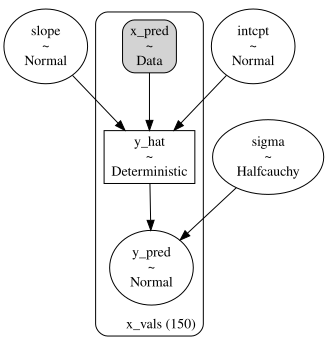

In [ ]:
x_grid = np.linspace(data.x.min(), data.x.max(), 150)
regress_pred = pm.Model()
with regress_pred:
    intcpt = pm.Normal("intcpt", 0, 5)
    slope  = pm.Normal("slope",  0, 5)
    sigma  = pm.HalfCauchy("sigma", 2)

    x_pred = pm.Data("x_pred", x_grid, dims="x_vals")
    y_hat = pm.Deterministic("y_hat", intcpt + slope * x_pred, dims="x_vals")
    y_pred = pm.Normal("y_pred", mu=y_hat, sigma=sigma, dims="x_vals")

    ppc = pm.sample_posterior_predictive(
        idata.posterior,
        var_names=["y_hat", "y_pred"]
    )
pm.model_to_graphviz(regress_pred)

**Chat**,
1. We've defined an infernece model and a seperate predictive model. Why is this seperation sensible? Is it required?
2. Why is `pm.sample_posterior_predictive()` not outputting MCMC diagnostics  like `pm.sample()`?
3. How can we draw samples of y_hat without running MCMC? Remember it's deterministic.
  - What about y? That one isn't deterministic.
    - https://idan-alter.github.io/2023/01/12/Ziggurat-Algorithm.html

In [ ]:
ppc

Inference data with groups:
	> posterior_predictive
	> constant_data

/tmp/ipykernel_4379/1383790828.py:20: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  ci_low, ci_high = az.hdi(y_hat_draws, 0.95).T       # function HDI
/tmp/ipykernel_4379/1383790828.py:21: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  pi_low, pi_high = az.hdi(y_pred_draws, 0.95).T      # predictive HDI


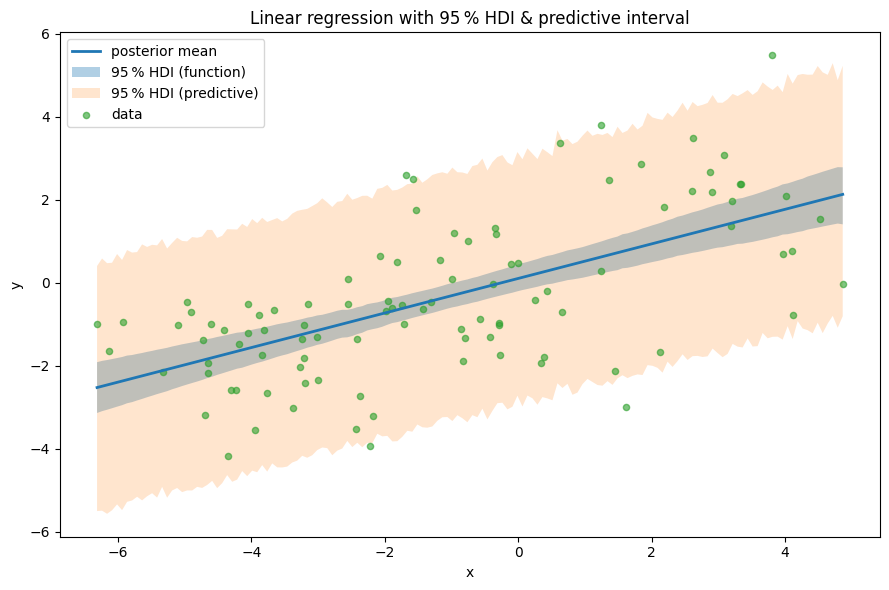

In [ ]:
#Chat, draw the regression line with HDIs, the data and predictive intervals on the same figure. make it pop.

# collapse (chain, draw) axes → sample axis
# 1.  stack → (sample, x_vals)  so shape = (6000, 150)
y_hat_draws = (
    ppc.posterior_predictive["y_hat"]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "x_vals")
        .values
)
y_pred_draws = (
    ppc.posterior_predictive["y_pred"]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "x_vals")
        .values
)


mean_line = y_hat_draws.mean(axis=0)
ci_low, ci_high = az.hdi(y_hat_draws, 0.95).T       # function HDI
pi_low, pi_high = az.hdi(y_pred_draws, 0.95).T      # predictive HDI

plt.figure(figsize=(9, 6))
plt.plot(x_grid, mean_line, lw=2, label="posterior mean")
plt.fill_between(x_grid, ci_low, ci_high, alpha=0.35,
                 label="95 % HDI (function)")
plt.fill_between(x_grid, pi_low, pi_high, alpha=0.20,
                 label="95 % HDI (predictive)")
plt.scatter(data.x, data.y, s=20, alpha=0.6, label="data")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Linear regression with 95 % HDI & predictive interval")
plt.legend(); plt.tight_layout(); plt.show()

**Chat**,
1. What's the difference between HDIs and PIs?
2. Why are the PIs are of constant size while the HDIs shrink towards the middle range?

# MCMC
- https://chi-feng.github.io/mcmc-demo/

Let's use a simpler model for this:

$$y = \beta_0 + \beta_1 \cdot x + N(0,1) $$


Output()

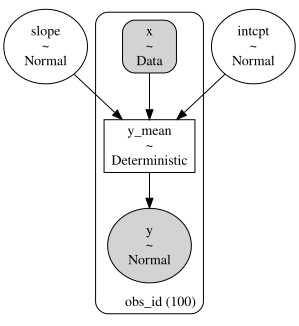

In [ ]:
regress = pm.Model()
with regress:
    #sigma = pm.HalfCauchy("sigma", beta=2)
    sigma = 1
    intcpt = pm.Normal("intcpt", 0, sigma=5)
    slope = pm.Normal("slope", 0, sigma=5)
    x = pm.Data("x", data.x, dims="obs_id")
    y_mean = pm.Deterministic("y_mean", intcpt + slope * x, dims="obs_id")
    pm.Normal("y", mu=y_mean, sigma=sigma, observed=data.y, dims="obs_id")
    idata = pm.sample(3000,chains=2)
pm.model_to_graphviz(regress)

<Axes: xlabel='intcpt', ylabel='slope'>

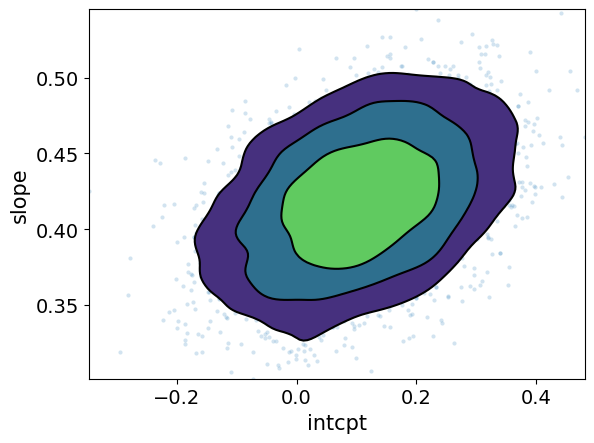

In [ ]:
az.plot_pair(idata,var_names=["~y_mean"],kind=["kde","scatter"],scatter_kwargs=dict(alpha=0.2))

**Chat**,
1. Why does the joint posterior distribution of slope and intcpt looks like a 2d gaussian?
2. How does pymc estimate the joint dist.? Mention MCMC and KDE.
3. Is it possible to approximate the joint posterior without sampling? Mention the **grid method**.

### The grid method

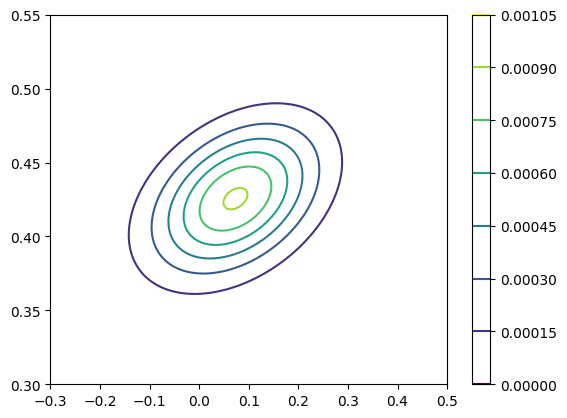

In [ ]:
n = 100
intcpt_sup = np.linspace(-0.3, 0.5, n)
slope_sup = np.linspace(0.3, 0.55, n)
prior_i = stats.norm.pdf(intcpt_sup, loc=0, scale=10)
prior_s = stats.norm.pdf(slope_sup, loc=0, scale=10)

likelihood = np.empty((n,n))
posterior = np.empty((n,n))
for i in range(n):
  for j in range(n):
    y_mean = intcpt_sup[i]+slope_sup[j]*data.x
    likelihood[i,j] = stats.norm.pdf(data.y,loc=y_mean,scale=1).prod()
    posterior[i,j] = prior_i[i] * prior_s[j] * likelihood[i,j]
    #Chat, Why is the previous line problematic? Mention underflow.
posterior /= posterior.sum()

contour = plt.contour(intcpt_sup, slope_sup, posterior)
plt.colorbar(contour)

**Chat**, Why is the grid method only viable for 1-3 parameters? Discuss: **1.** The Computational complexity, **2.** The curse of dimensionality and specifically the inadequacy of a grid in capturing the support of the posterior. 3. Having to know the support of the posterior before seeing the data.


### MCMC Diagnostics
**Chat**,
1. What are common failure modes of Metropolis-Hastings with a Gaussian proposal?
2. What makes a proposal heuristic good?
3. What's Hamiltonian MC? Explain as if I know no physics.
4. How does NUTS improve on HMC?
5. HMC and NUTS require the gradients of the (log) posterior, but we're using these algorithms to estimate the posterior. How does PyMC calculate these gradients? Explain with the regression example from before.
6. What happens if my model has discrete parameters? How does PyMC generates MCMC samples?

## Hierarchical regression
Back to Simpson's paradox.
#### Bad MCMC:

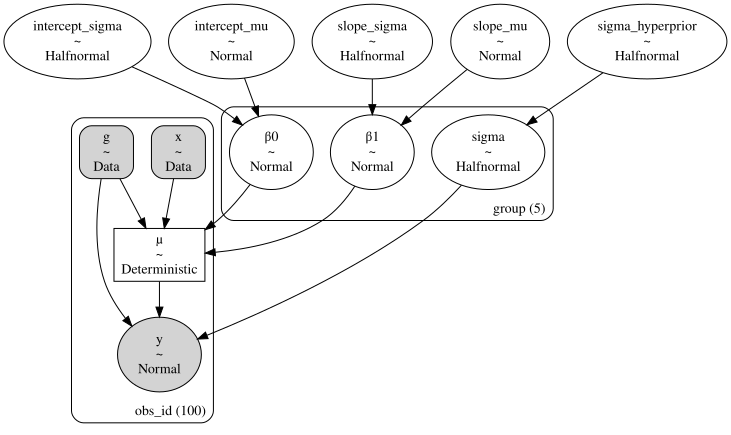

In [ ]:
coords = {"group": group_list}
with pm.Model(coords=coords) as hierarchical:
    # Hyperpriors
    intercept_mu = pm.Normal("intercept_mu", 0, sigma=1)
    intercept_sigma = pm.HalfNormal("intercept_sigma", sigma=2)
    slope_mu = pm.Normal("slope_mu", 0, sigma=1)
    slope_sigma = pm.HalfNormal("slope_sigma", sigma=2)
    sigma_hyperprior = pm.HalfNormal("sigma_hyperprior", sigma=0.5)

    # Define priors
    sigma = pm.HalfNormal("sigma", sigma=sigma_hyperprior, dims="group")

    β0 = pm.Normal("β0", intercept_mu, sigma=intercept_sigma, dims="group")
    β1 = pm.Normal("β1", slope_mu, sigma=slope_sigma, dims="group")

    # Data
    x = pm.Data("x", data.x, dims="obs_id")
    g = pm.Data("g", data.group_idx, dims="obs_id")
    # Linear model
    μ = pm.Deterministic("μ", β0[g] + β1[g] * x, dims="obs_id")
    # Define likelihood
    pm.Normal("y", mu=μ, sigma=sigma[g], observed=data.y, dims="obs_id")
pm.model_to_graphviz(hierarchical)

In [ ]:
with hierarchical:
  idata = pm.sample(300,chains=2)

Output()

ERROR:pymc.stats.convergence:There were 28 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


**Chat**, <Copy & paste>  Should I worry?

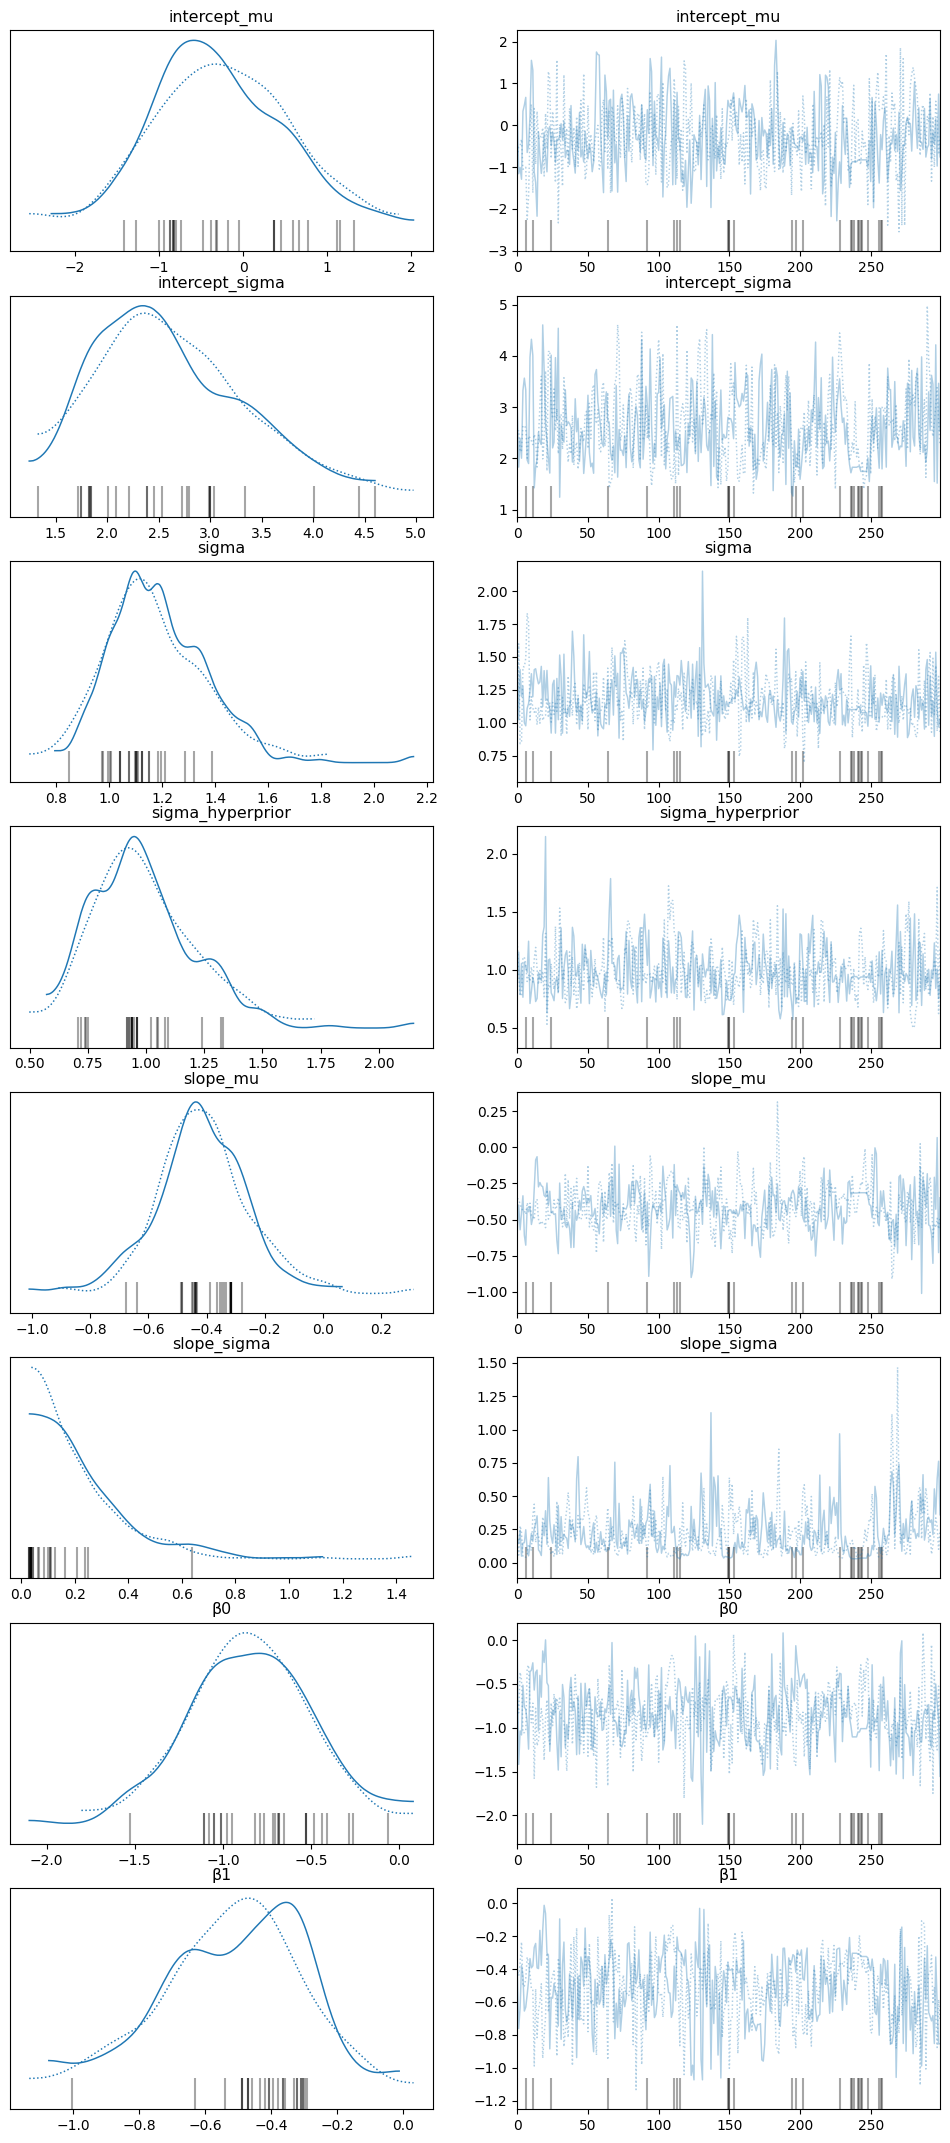

In [ ]:
az.plot_trace(idata, var_names=["~μ"],coords = {"group": "one"},  figsize = (12, 9 * 3));

- Anomaly #1: The KDEs are different, but both chains should converge to the **same** limiting dist.
- Anomaly #2: between t=X and t=Y a chain got stuck.



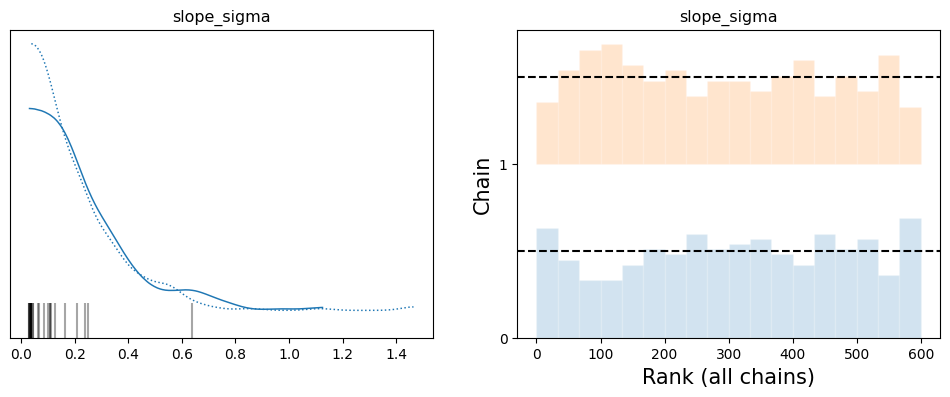

In [ ]:
az.plot_trace(idata, kind="rank_bars", var_names=["slope_sigma"],coords = {"group": "three"},  figsize = (12, 4));
#bars x-axis: samples.flatten().sort()
#bars y-axis: hist(x) per chain
#with good mixing: sample.chain should be random.

**Chat**, explain this figure.

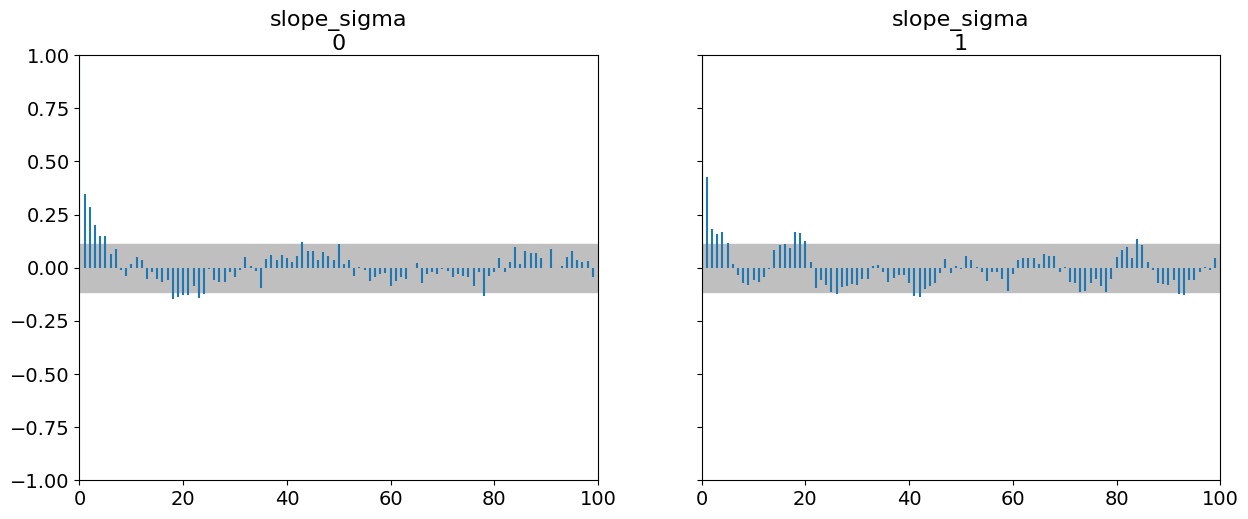

In [ ]:
az.plot_autocorr(idata, var_names=["slope_sigma"]);
#x axis = lag

**Chat**, how does arviz calculate the autocorrelation here?


# What causes the problem?
  - https://chi-feng.github.io/mcmc-demo/app.html?algorithm=RandomWalkMH&target=funnel

**Chat**,
1. Explain what Neal's funnel is and why the Metropolis algorithm with fixed gaussian steps fails at sampling it.
2. What are divergences in HMC? Why do they occur in Neal's funnel? Explain as if I know no physics. What does the algorithm do when a step diverges?
3. <Copy & paste the model definition> Where does a funnel occur in my model?

/usr/local/lib/python3.12/dist-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


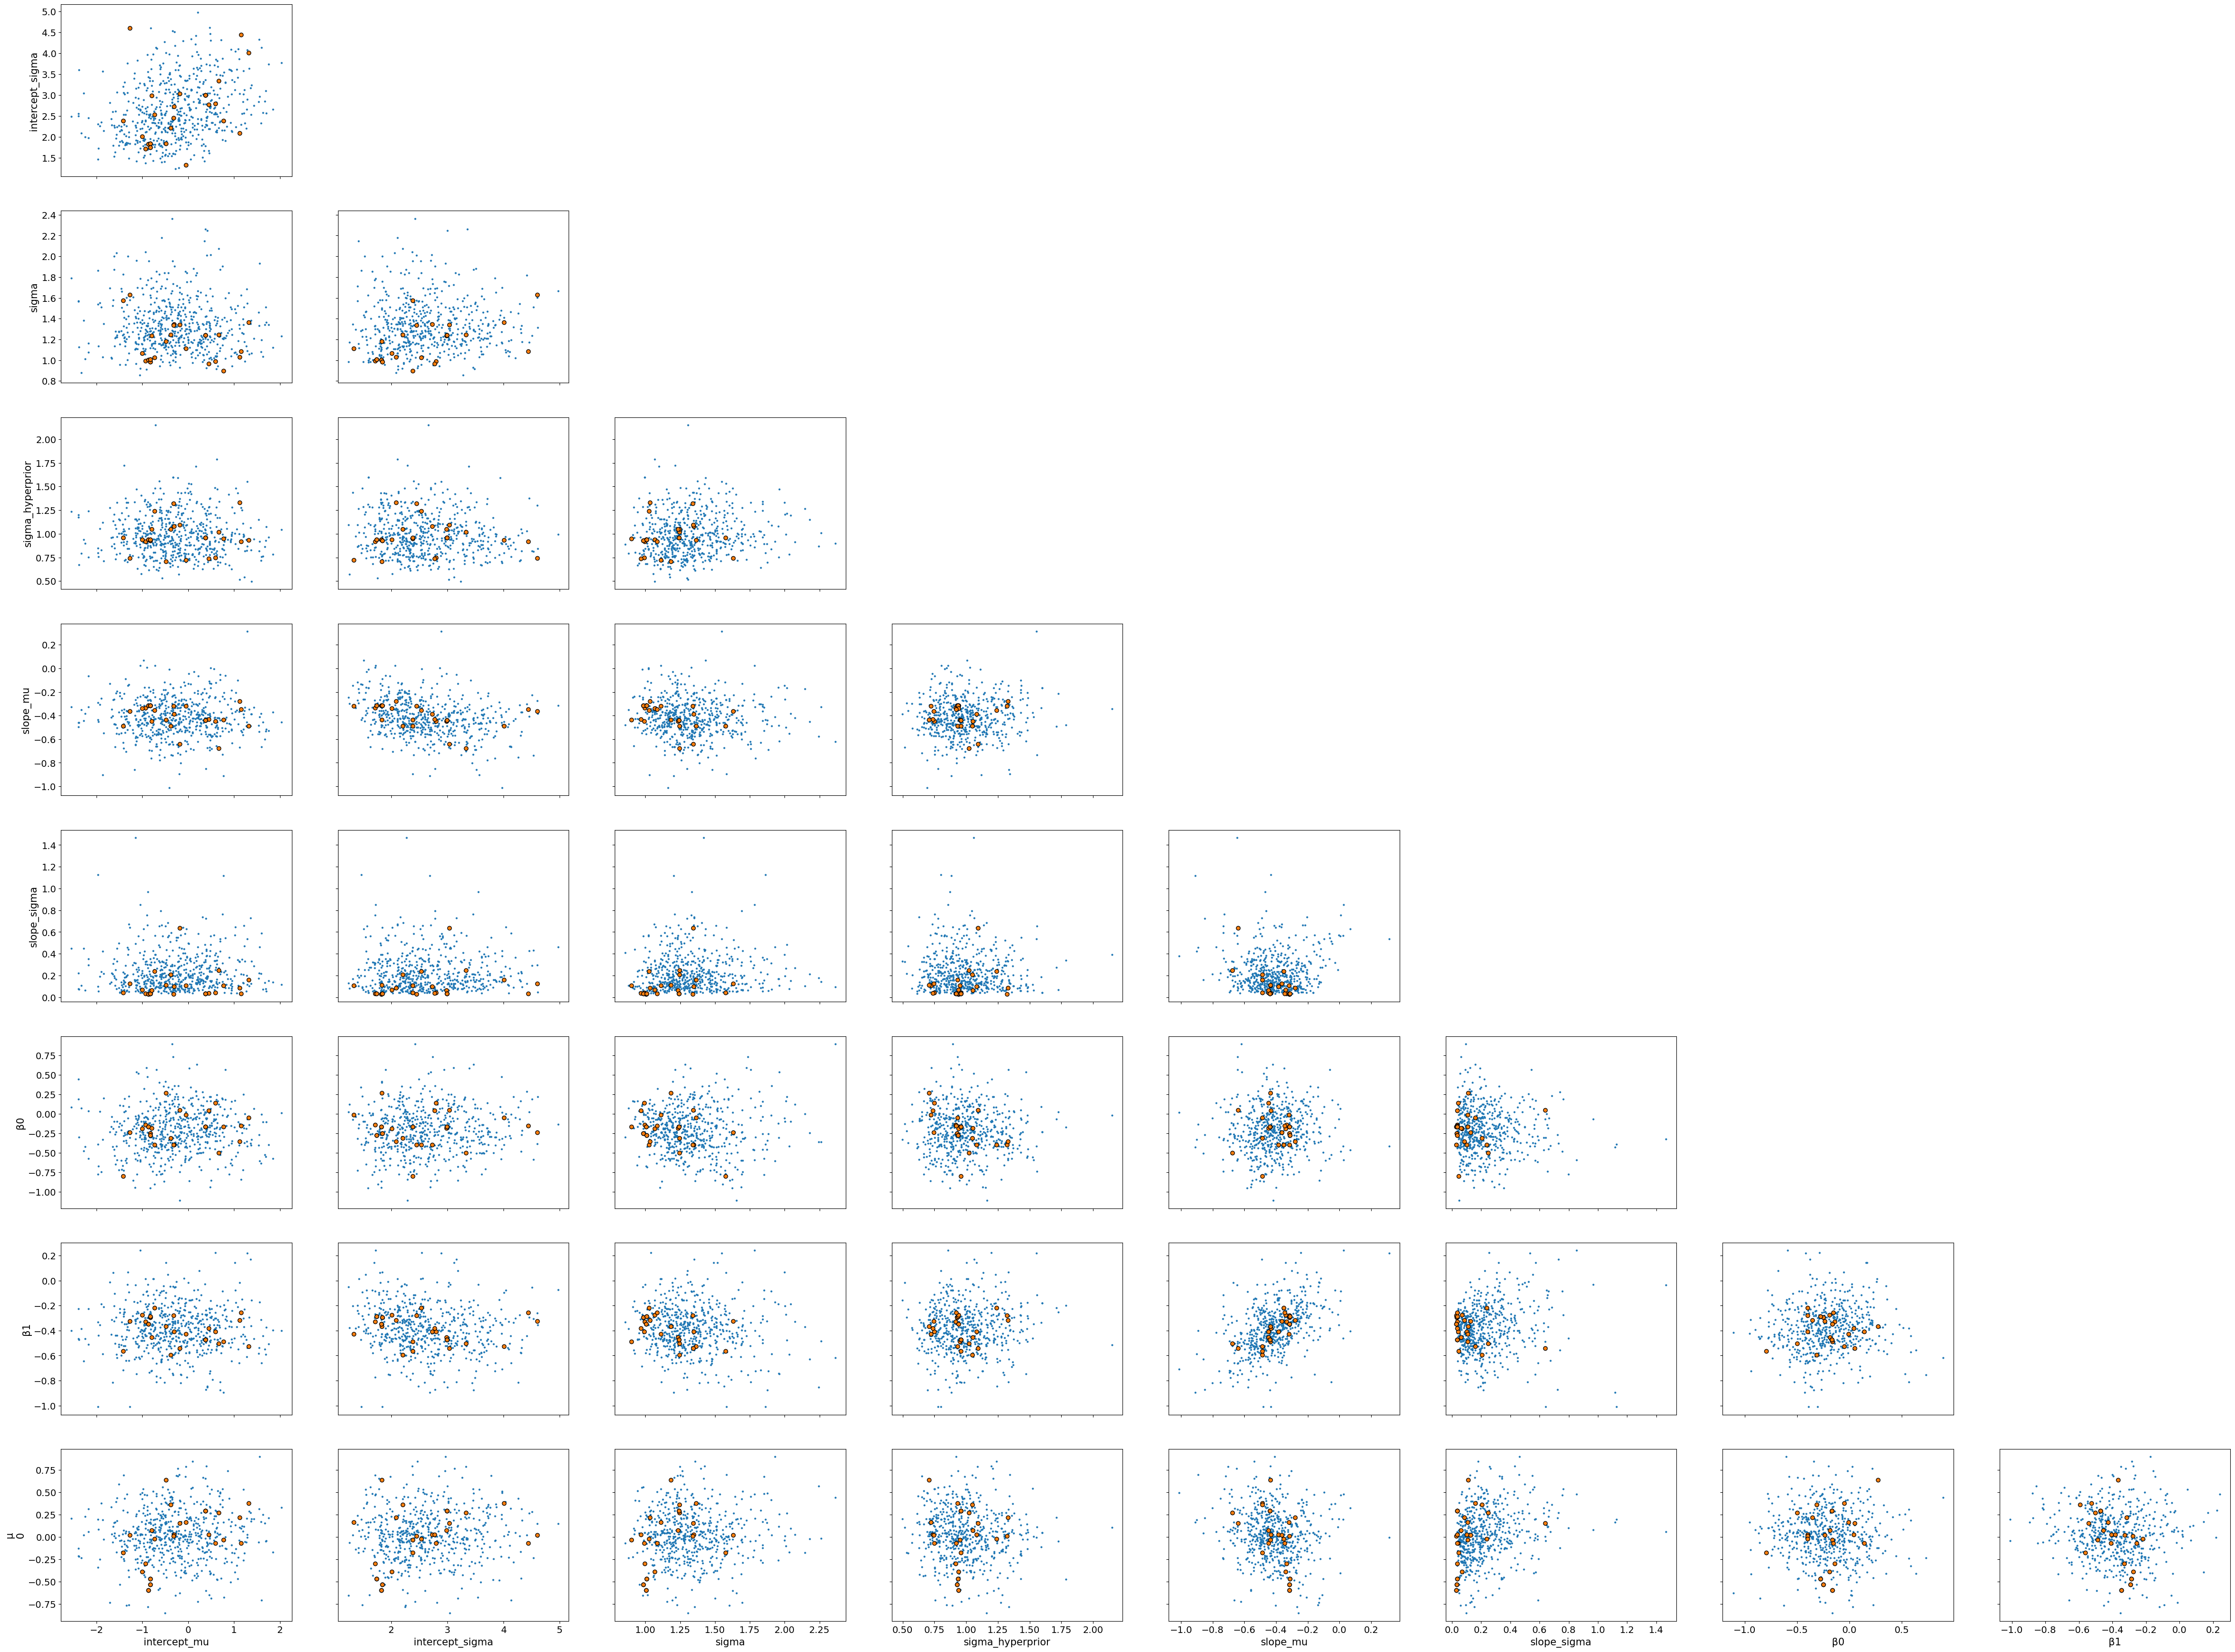

In [ ]:
az.plot_pair(idata,coords = {"group": "two"}, kind='scatter', divergences=True);

array([[<Axes: ylabel='β1\ntwo'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='β1\nthree'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='β1\nfour'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: ylabel='β1\nfive'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >],
       [<Axes: xlabel='β1\none', ylabel='slope_sigma'>,
        <Axes: xlabel='β1\ntwo'>, <Axes: xlabel='β1\nthree'>,
        <Axes: xlabel='β1\nfour'>, <Axes: xlabel='β1\nfive'>]],
      dtype=object)

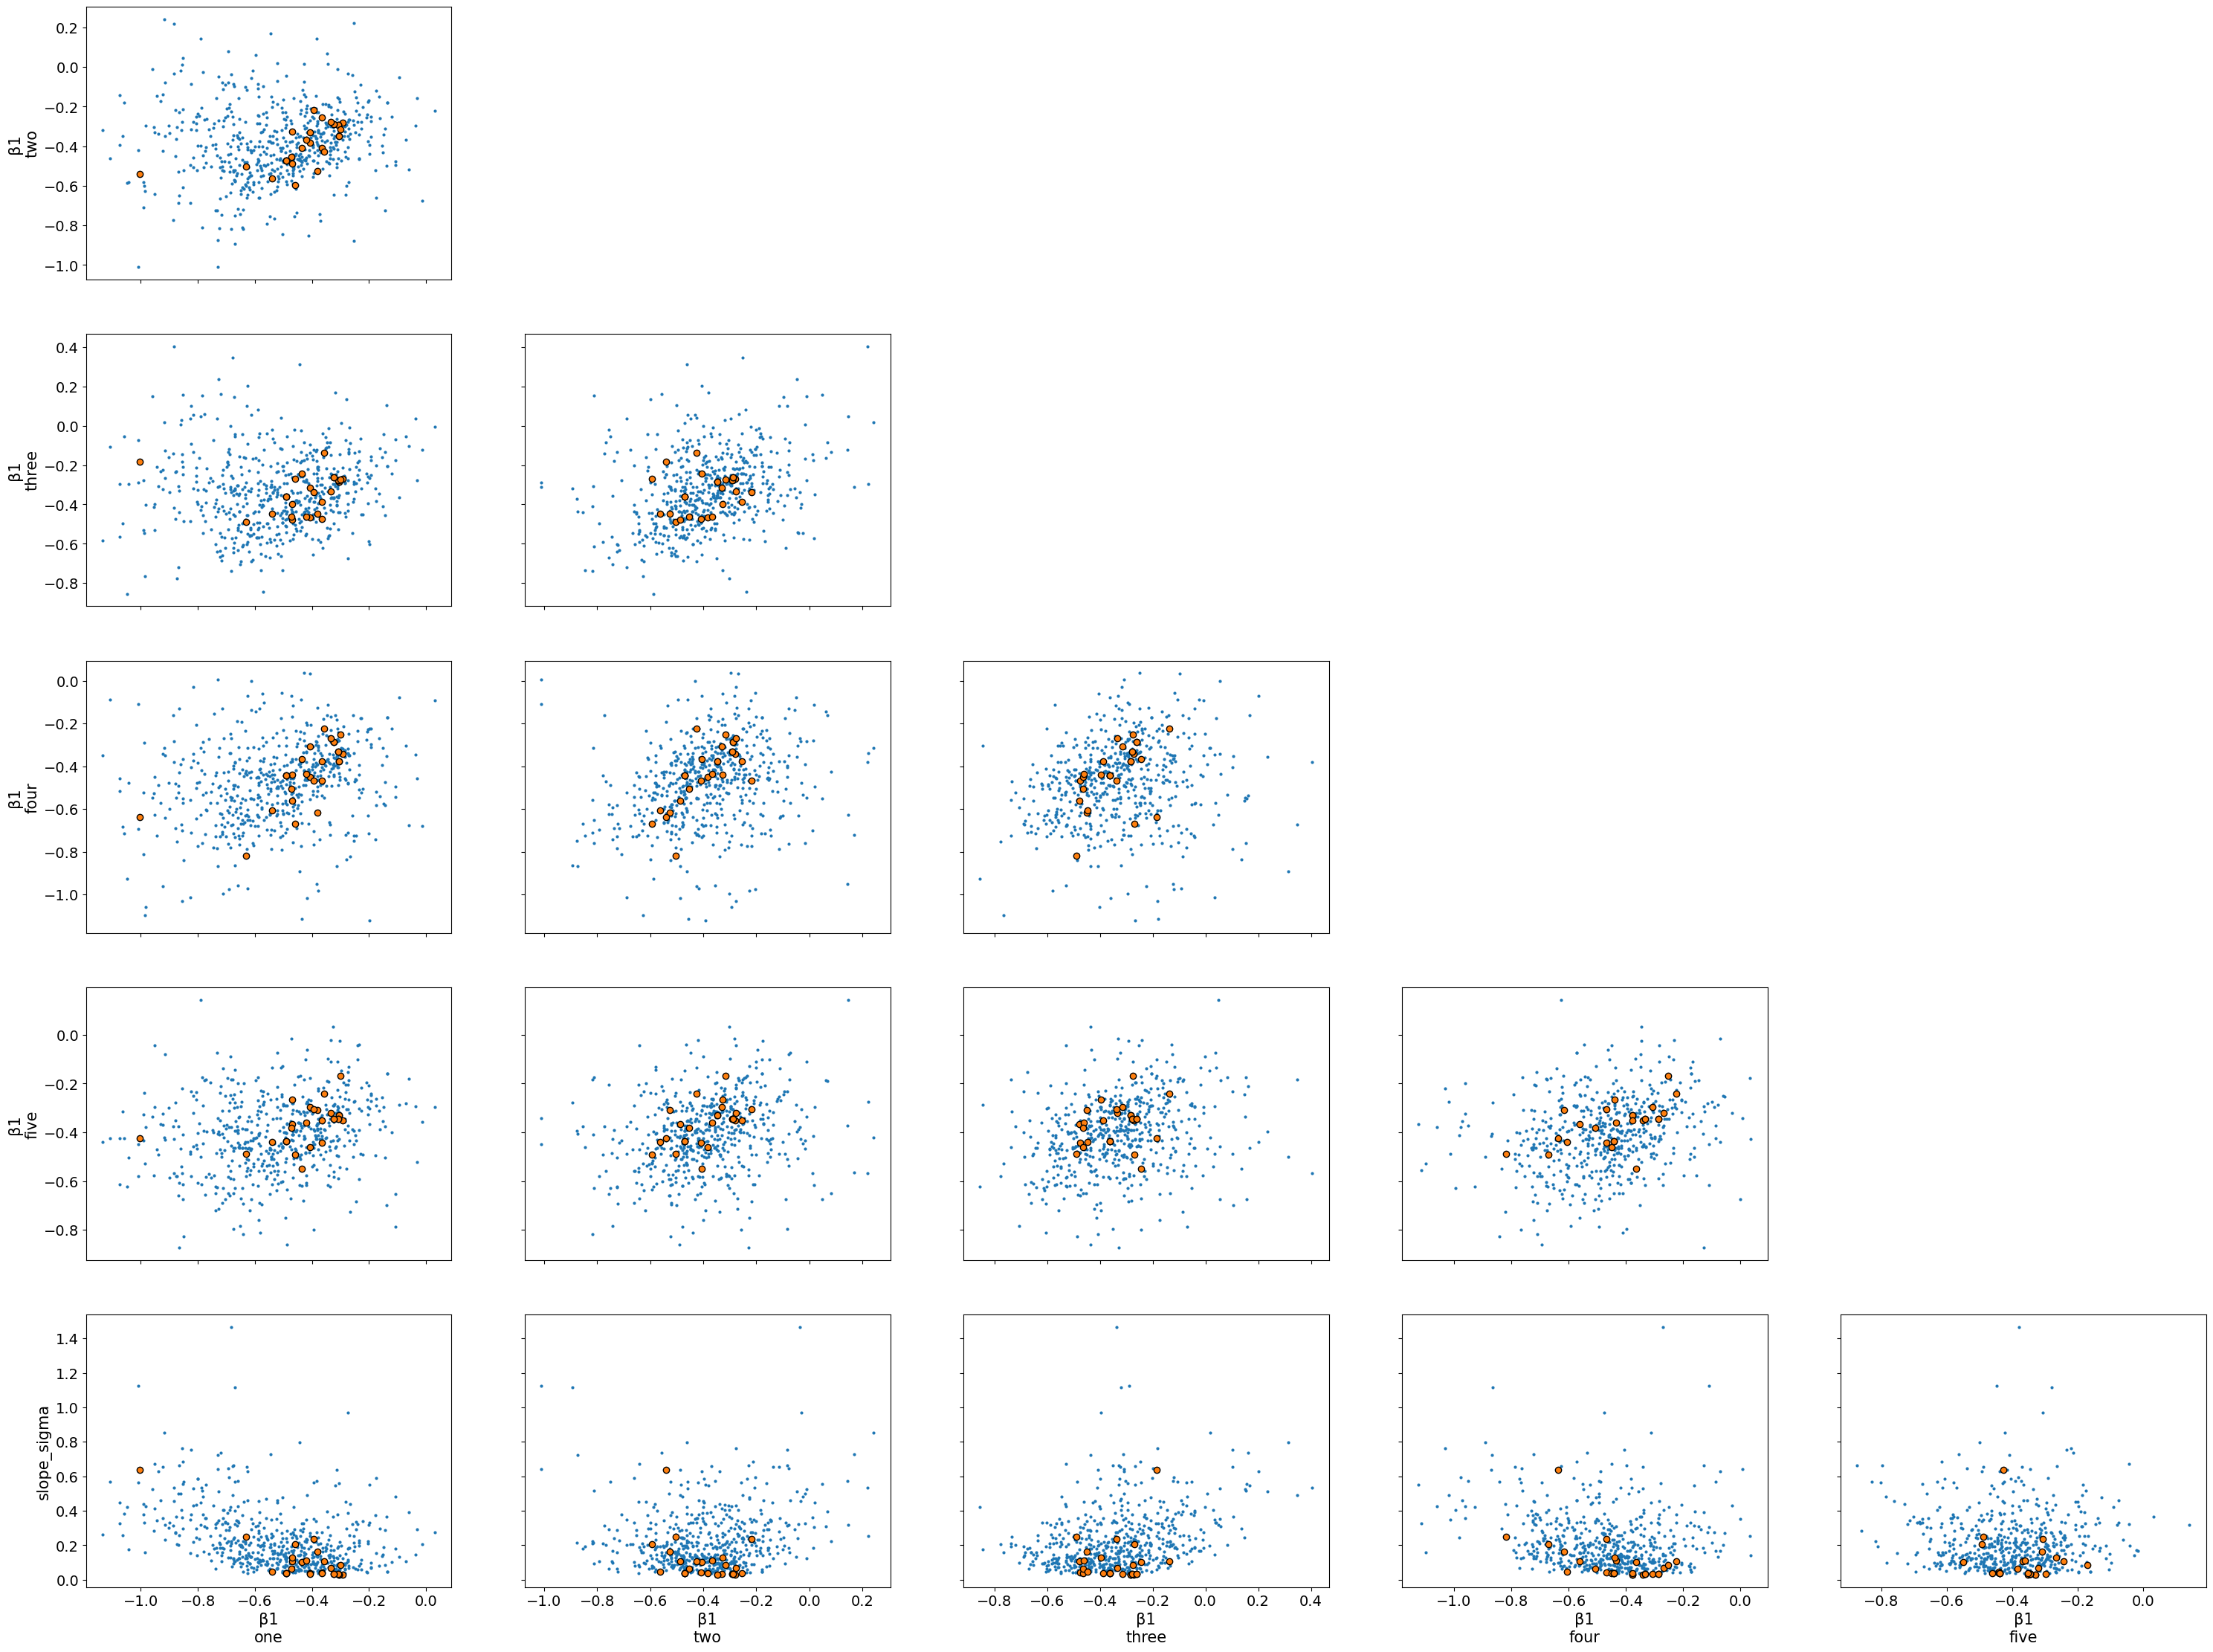

In [ ]:
az.plot_pair(idata, var_names=["β1", "slope_sigma"], divergences=True)

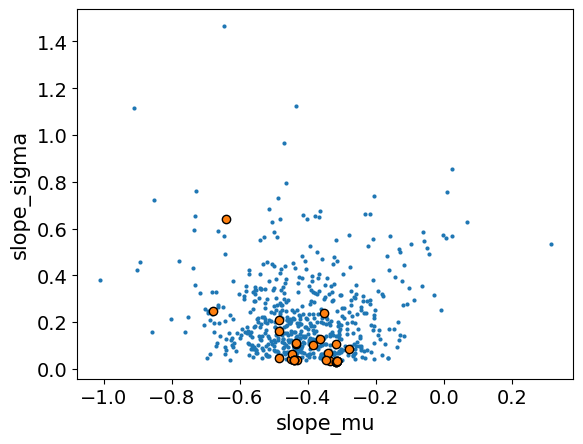

In [ ]:
az.plot_pair(idata,var_names=['slope_mu','slope_sigma'], coords = {"group": "two"}, kind='scatter', divergences=True);

# Quantitative diagnostics

In [ ]:
az.summary(idata,var_names=["β1", "slope_sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β1[one],-0.517,0.209,-0.919,-0.135,0.013,0.009,243.0,335.0,1.0
β1[two],-0.385,0.184,-0.755,-0.032,0.008,0.010,523.0,393.0,1.0
β1[three],-0.332,0.188,-0.690,0.014,0.010,0.008,343.0,442.0,1.0
β1[four],-0.475,0.191,-0.788,-0.088,0.011,0.008,275.0,468.0,1.0
β1[five],-0.405,0.150,-0.695,-0.131,0.008,0.007,339.0,365.0,1.0
slope_sigma,0.222,0.177,0.030,0.561,0.013,0.013,130.0,109.0,1.0


**Chat**,
1. <Copy & paste> What do we see here?
2. What's r_hat? What value of it should make me worry? Take this blog post into account: https://statmodeling.stat.columbia.edu/2019/03/19/maybe-its-time-to-let-the-old-ways-die-or-we-broke-r-hat-so-now-we-have-to-fix-it/
3. What's ess_bulk and ess_tail? We used MCMC to sample 2000 samples from the posterior, why are these numbers lower?


<Axes: title={'center': 'β1'}, xlabel='Quantile', ylabel='ESS for small intervals'>

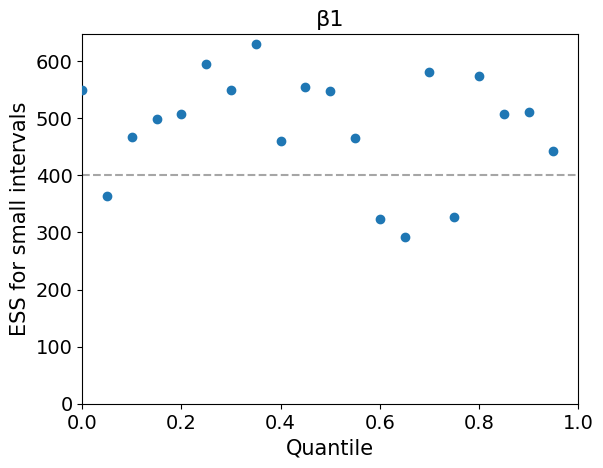

In [ ]:
az.plot_ess(idata,var_names=["β1"],coords = {"group": "three"})

array([<Axes: title={'center': 'β1'}, xlabel='Total number of draws', ylabel='ESS'>,
       <Axes: title={'center': 'slope_sigma'}, xlabel='Total number of draws', ylabel='ESS'>],
      dtype=object)

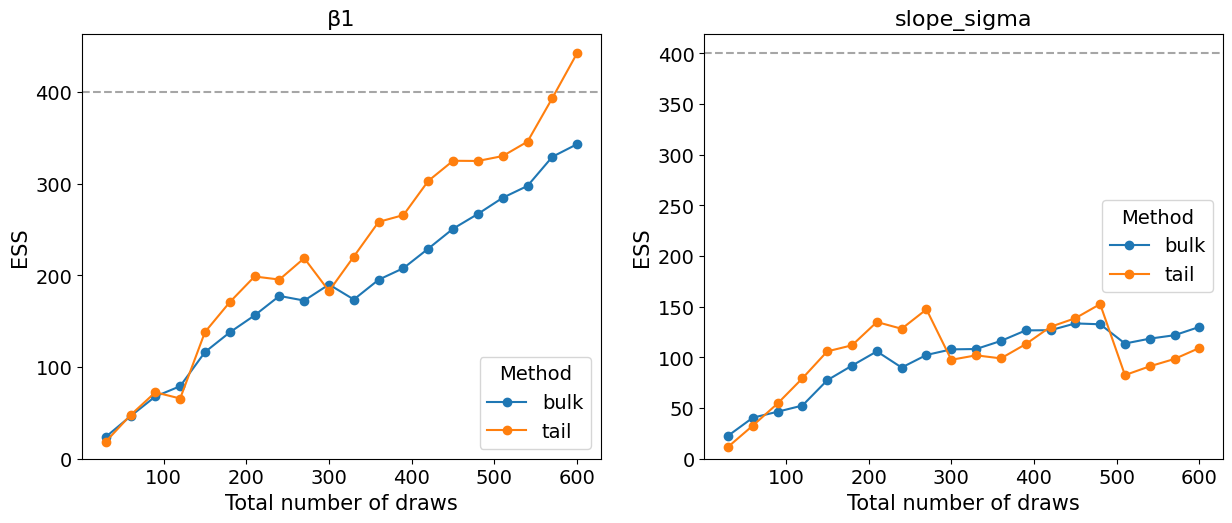

In [ ]:
az.plot_ess(idata,var_names=["β1", "slope_sigma"],coords = {"group": "three"},kind='evolution')

**Chat**, why is 400 the magic number for ESS? Mention MCSE estimates.

#Solutions:

1. Brute force: Run more chains, longer. if the ess trend shows hope - this might work.

2. Reparameterization: same theoretical model, defined differently.

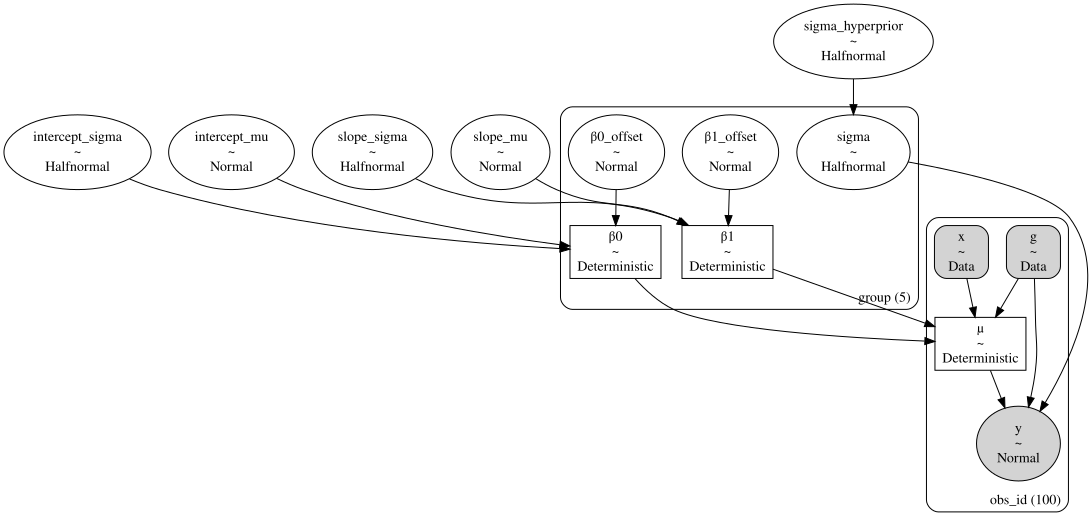

In [ ]:
with pm.Model(coords=coords) as hierarchical_nc: #non-centered
    # Hyperpriors
    intercept_mu = pm.Normal("intercept_mu", 0, sigma=1)
    intercept_sigma = pm.HalfNormal("intercept_sigma", sigma=2)
    slope_mu = pm.Normal("slope_mu", 0, sigma=1)
    slope_sigma = pm.HalfNormal("slope_sigma", sigma=2)
    sigma_hyperprior = pm.HalfNormal("sigma_hyperprior", sigma=0.5)

    # Define priors
    sigma = pm.HalfNormal("sigma", sigma=sigma_hyperprior, dims="group")
#######
    # β0 = pm.Normal("β0", intercept_mu, sigma=intercept_sigma, dims="group")
    # β1 = pm.Normal("β1", slope_mu, sigma=slope_sigma, dims="group")

    β0_offset = pm.Normal("β0_offset", 0, sigma=1, dims="group")
    β0 = pm.Deterministic("β0", intercept_mu + β0_offset * intercept_sigma, dims="group")
    β1_offset = pm.Normal("β1_offset", 0, sigma=1, dims="group")
    β1 = pm.Deterministic("β1", slope_mu + β1_offset * slope_sigma, dims="group")
#######

    # Data
    x = pm.Data("x", data.x, dims="obs_id")
    g = pm.Data("g", data.group_idx, dims="obs_id")
    # Linear model
    μ = pm.Deterministic("μ", β0[g] + β1[g] * x, dims="obs_id")
    # Define likelihood
    pm.Normal("y", mu=μ, sigma=sigma[g], observed=data.y, dims="obs_id")
pm.model_to_graphviz(hierarchical_nc)

**Chat**,
1. <Copy & paste> What's the difference  between this model and the old one? How does it solve the funnel problem?
2. Where have I seen this trick before? (Hint: VAE).
3. Draw a graphviz diagram of a VAE with and without the reparameterization trick

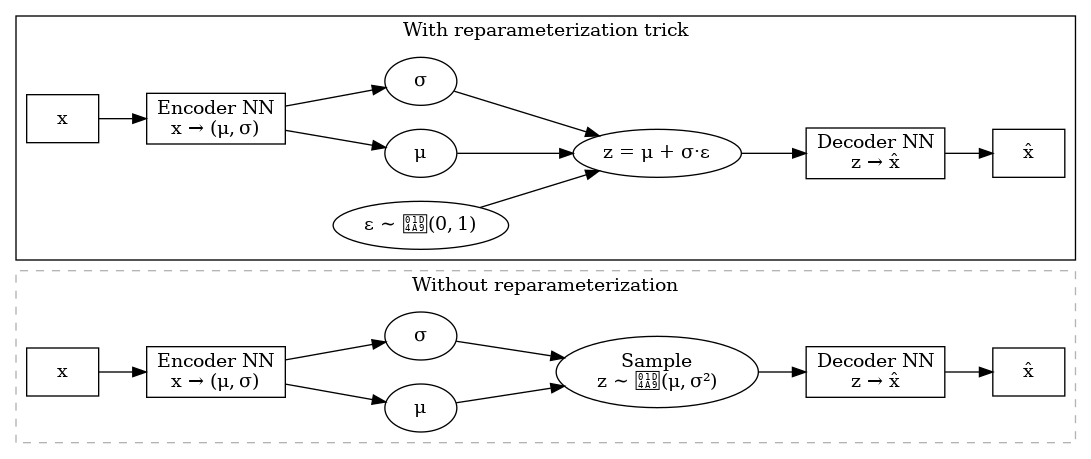

In [ ]:
with hierarchical_nc:
  idata_nc = pm.sample(1000,chains=2)

Output()

ERROR:pymc.stats.convergence:There were 8 divergences after tuning. Increase `target_accept` or reparameterize.


In [ ]:
az.summary(idata_nc,var_names=["β1", "slope_sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
β1[one],-0.502,0.207,-0.944,-0.147,0.005,0.005,1490.0,1575.0,1.0
β1[two],-0.382,0.175,-0.703,-0.048,0.004,0.004,1832.0,1381.0,1.0
β1[three],-0.338,0.190,-0.717,0.020,0.006,0.005,1221.0,840.0,1.0
β1[four],-0.448,0.187,-0.816,-0.119,0.007,0.008,928.0,508.0,1.0
β1[five],-0.395,0.158,-0.701,-0.106,0.004,0.004,1620.0,1389.0,1.0
slope_sigma,0.198,0.171,0.000,0.510,0.006,0.006,859.0,1015.0,1.0


#Go Further:
1. https://www.pymc.io/projects/examples/en/latest/diagnostics_and_criticism/Diagnosing_biased_Inference_with_Divergences.html
2. https://statmodeling.stat.columbia.edu/2021/06/10/when-mcmc-fails-the-advice-were-giving-is-wrong-heres-what-we-you-should-be-doing-instead-hint-its-all-about-the-folk-theorem/